# Ejercicio de Regresión 1 (Core)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Carga de datos**

In [2]:
df = pd.read_csv('house-prices.csv')

**Exploracion de datos**

In [3]:
print("Primeras filas del DataFrame:")
display(df.head(10))

print("Ultimas filas del DataFrame:")
print(df.tail(5))

print("Informacion del DataFrame:")
print(df.info())

Primeras filas del DataFrame:


,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East
5,6,114600,1780,3,2,2,No,North
6,7,151600,1830,3,3,3,Yes,West
7,8,150700,2160,4,2,2,No,West
8,9,119200,2110,4,2,3,No,East
9,10,104000,1730,3,3,3,No,East


Ultimas filas del DataFrame:
     Home   Price  SqFt  Bedrooms  Bathrooms  Offers Brick Neighborhood
123   124  119700  1900         3          3       3   Yes         East
124   125  147900  2160         4          3       3   Yes         East
125   126  113500  2070         2          2       2    No        North
126   127  149900  2020         3          3       1    No         West
127   128  124600  2250         3          3       4    No        North
Informacion del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Home          128 non-null    int64
 1   Price         128 non-null    int64
 2   SqFt          128 non-null    int64
 3   Bedrooms      128 non-null    int64
 4   Bathrooms     128 non-null    int64
 5   Offers        128 non-null    int64
 6   Brick         128 non-null    str  
 7   Neighborhood  128 non-null    str  
dtypes: i

In [4]:
print("Estadisticas descriptivas del DataFrame:")
print(df.describe())

Estadisticas descriptivas del DataFrame:
             Home          Price         SqFt    Bedrooms   Bathrooms  \
count  128.000000     128.000000   128.000000  128.000000  128.000000   
mean    64.500000  130427.343750  2000.937500    3.023438    2.445312   
std     37.094474   26868.770371   211.572431    0.725951    0.514492   
min      1.000000   69100.000000  1450.000000    2.000000    2.000000   
25%     32.750000  111325.000000  1880.000000    3.000000    2.000000   
50%     64.500000  125950.000000  2000.000000    3.000000    2.000000   
75%     96.250000  148250.000000  2140.000000    3.000000    3.000000   
max    128.000000  211200.000000  2590.000000    5.000000    4.000000   

           Offers  
count  128.000000  
mean     2.578125  
std      1.069324  
min      1.000000  
25%      2.000000  
50%      3.000000  
75%      3.000000  
max      6.000000  


In [14]:
print("Tipos originales:")
print(df.dtypes)

Tipos originales:
Home            int64
Price           int64
SqFt            int64
Bedrooms        int64
Bathrooms       int64
Offers          int64
Brick             str
Neighborhood      str
dtype: object


In [5]:
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 0


In [6]:
print("Verificacion de datos nulos:")
print(df.isnull().sum())

Verificacion de datos nulos:
Home            0
Price           0
SqFt            0
Bedrooms        0
Bathrooms       0
Offers          0
Brick           0
Neighborhood    0
dtype: int64


Para este data set logramos determinar que no contamos con datos nulo ni duplicados

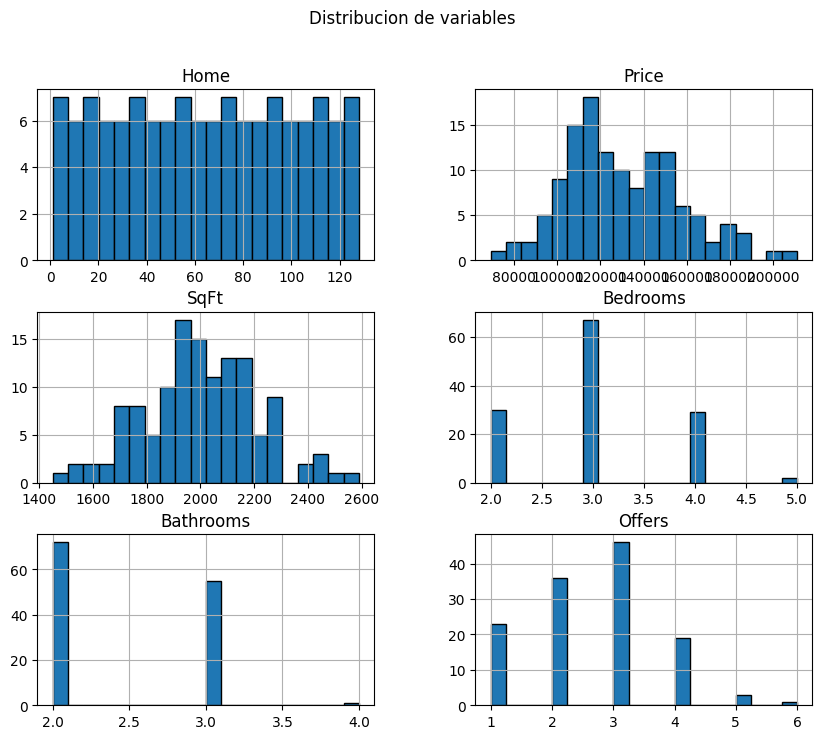

In [7]:
df.hist(figsize=(10,8), bins=20, edgecolor='black')
plt.suptitle('Distribucion de variables')
plt.show()

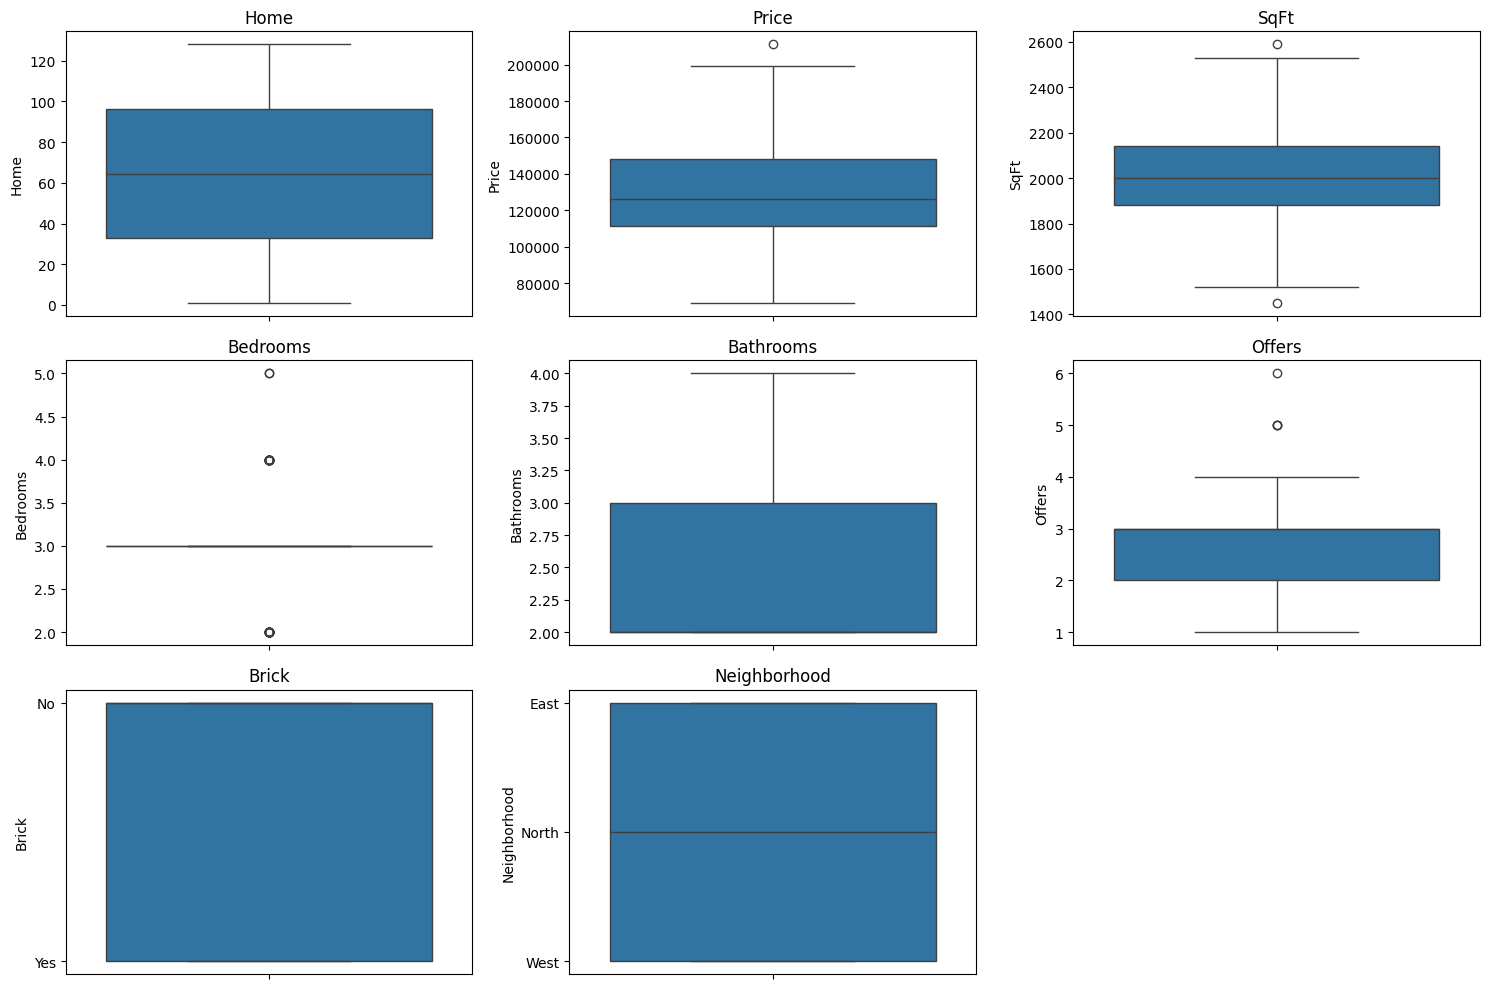

In [8]:
plt.figure(figsize=(15,10))
for i, col in enumerate(df.columns, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

**Preparacion de datos**

In [9]:
X = df[['SqFt', 'Bedrooms', 'Bathrooms']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Entrenar modelo**

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

**Evaluacion del modelo**

In [11]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('\nMSE:')
print(mse)

print('\nR²:')
print(r2)


MSE:
320149938.23026824

R²:
0.4568195777548877


**Prediccion nueva casa**

In [12]:
new_house = pd.DataFrame({'SqFt': [2000], 'Bedrooms': [3], 'Bathrooms': [2]})
predicted_price = model.predict(new_house)
print('\nPrecio predicho para la nueva casa:\n')
print(predicted_price[0])


Precio predicho para la nueva casa:

123536.9969321844


**Visualizacion de resultados**

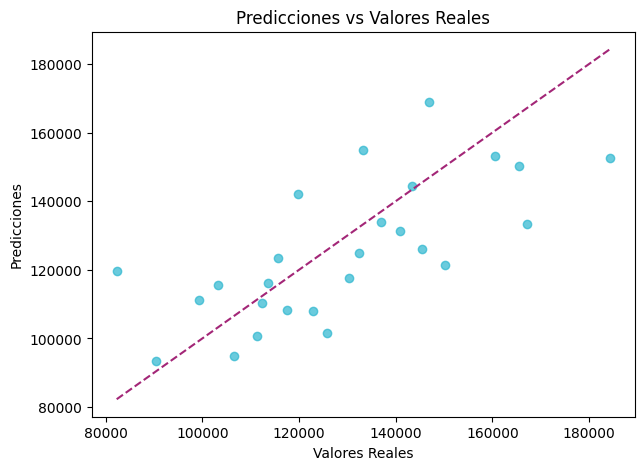

In [13]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.7, color='#2BB6CF')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='#A32677', linestyle='--')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.show()

Para este dataset se construyo un modelo de regresion lineal para predecir precios de casas utilizando tamaño, numero de habitaciones y numero de baños. Luego de entrenar el modelo con los datos de entrenamiento, se evaluo utilizando MSE y R sobre el conjunto de prueba. Finalmente, el modelo fue utilizado para estimar el precio de una nueva casa de 2000 pies cuadrados, 2 habitaciones y 2 baños.

Tambien se agrego un grafico de dispersion donde se muestra una relacion positiva entre los valores reales y las prediciiones del modelo de regresion lineal. La mayoria de los puntos siguen la tendencia de la linea ideal, indicando que el modelo logra capturar parcialmente el comportamiento de los precios de las casas. Sin embargo, existe dispercion alrededor de la linea, lo que evidencia errores de prediccion, especialmente en valores altos, donde el modelo presenta menor precision.